# Capstone — When does physics emerge in CaloDiffusion?

**Read `START_HERE.md` first** (the idea) and skim `JUMPING_OFF_POINTS.md` (the plan &
deliverables). This notebook gets you to **M0** (tools working) and scaffolds the **core**
measurement — the emergence curves and lock-in steps of four observables along the x̂₀
trajectory. The physics (the observables, the lock-in, the interpretation) is left to you as
`TODO`s on purpose.

## 0 · Setup

In [11]:
import sys, os
try:
    import calodiff_probe as cp          # works when run from this folder
except ModuleNotFoundError:              # or from the repo root
    sys.path.insert(0, 'capstone/calodiffusion')
    import calodiff_probe as cp
import numpy as np, torch, matplotlib.pyplot as plt
print('running on:', cp.DEVICE)   # 'cuda' on the GPU box, else 'cpu' (generation is slow on cpu)

running on: cuda


## 1 · Warm-up → **M0** (worked — just run these)

Get the tools in your hands before the real work. Nothing here is graded; it de-risks the API.

### 1a · What a shower looks like
A real shower as a **layer × radius** heatmap (summed over the angular axis).



 Model: 

Event start, stop:  0 16
dset 2


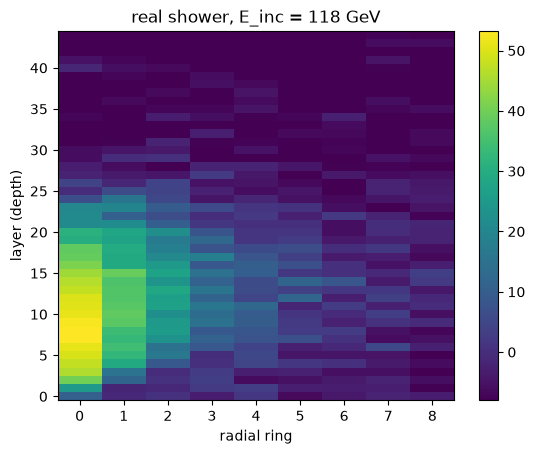

In [12]:
model = cp.load_model('electron')
x, E, E_inc = cp.load_showers('electron', n=16)
grid = cp.regular_grid(model, x)          # (16, layer=45, angular=16, radial=9)
plt.imshow(grid[0].sum(axis=1), aspect='auto', origin='lower')
plt.xlabel('radial ring'); plt.ylabel('layer (depth)')
plt.title(f'real shower, E_inc = {E_inc[0]:.0f} GeV'); plt.colorbar(); plt.show()

### 1b · The forward (noising) process
The model learns to *reverse* this. Watch a shower dissolve into noise.

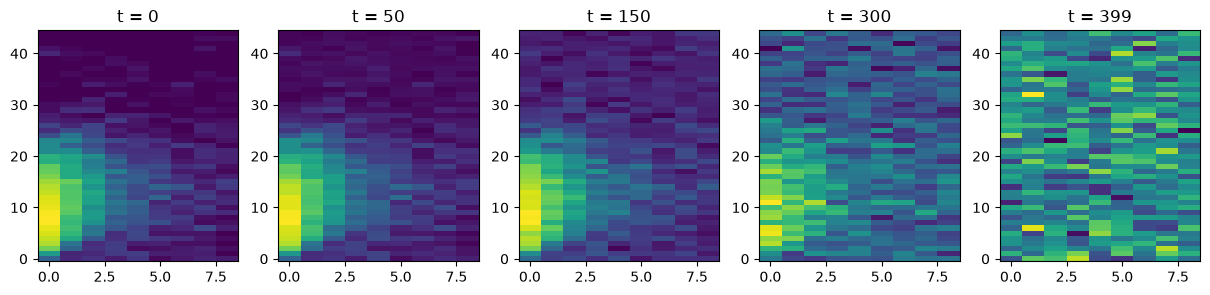

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, t in zip(axes, [0, 50, 150, 300, 399]):
    x_t, _ = cp.noise_at(model, x, t)
    ax.imshow(cp.regular_grid(model, x_t)[0].sum(1), aspect='auto', origin='lower')
    ax.set_title(f't = {t}')
plt.show()

### 1c · Does the model actually denoise?
It predicts the noise added at step `t`; the prediction should correlate with the truth (~0.9).

In [14]:
x_t, eps = cp.noise_at(model, x, t=100)
eps_hat  = cp.predict_noise(model, x_t, E, t=100)
corr = torch.corrcoef(torch.stack([eps_hat.flatten(), eps.flatten()]))[0, 1]
print(f'corr(predicted, true noise) = {corr:.3f}   # ~0.9 = the model works')

corr(predicted, true noise) = 0.906   # ~0.9 = the model works


---
## 2 · The core — emergence curves & lock-in  → **M1 / M2**

As the model builds a shower from noise, it produces at every step a running guess of the
finished shower: **x̂₀** (START_HERE §2). We compute physics on x̂₀ **in physical units** at
each step and ask: *in what order do the observables settle?*

### 2a · Get the x̂₀ trajectory (worked)
⚠️ Generation is slow on CPU — keep `n` small here; move to the **GPU** for real runs.
`x0s` is the per-step list of x̂₀ frames (index 0 = noisiest ... last = clean).

In [15]:
n = 8
E_inc_gev = [50.] * n                     # fixed energy for the core measurement
E_cond = cp.encode_energy('electron', E_inc_gev)
x_final, xs, x0s = cp.sample(model, E_cond, debug=True)
print(f'{len(x0s)} trajectory frames, each {np.asarray(x0s[0]).shape}')
# convert one frame to physical GeV to see the shape you'll work with:
print('one frame -> physical grid:', cp.to_physical_grid(model, x0s[-1], E_inc_gev).shape,
      '= (n, layer, angular, radial)')

SAMPLE ALGO : ddpm
Time for sampling 8 events is 5.05462384223938 seconds
398 trajectory frames, each (8, 1, 45, 16, 9)
dset 2
one frame -> physical grid: (8, 45, 16, 9) = (n, layer, angular, radial)


### 2b · The four observables  ⟵ **your job**
Each takes a physical grid `g` of shape `(N, layer, angular, radial)` and returns one number
**per shower** (an array of length N). One is done as the pattern; write the other three.

- `total_energy` — sum of all cell energies *(worked, shows the pattern)*
- `depth` — energy-weighted **mean layer index** (how deep the shower peaks)
- `radial_spread` — energy-weighted **RMS radius** (how wide it is)
- `occupancy` — fraction of cells above a **fixed** threshold `ecut` *(use `model.config['ECUT']`)*

In [16]:
def total_energy(g):                       # (N, layer, ang, rad) -> (N,)
    return g.sum(axis=(1, 2, 3))

def depth(g):
    layer_energy = g.sum(axis=(2,3))
    layers = np.arange(g.shape[1])
    total_energy = layer_energy.sum(axis=1)
    return (layer_energy * layers).sum(axis=1) / total_energy

def radial_spread(g):
    radial_energy = g.sum(axis=(1,2))
    r = np.arange(g.shape[3])
    total_energy = radial_energy.sum(axis=1)
    mean_r = (radial_energy * r).sum(axis=1) / total_energy
    r_diff_sq = (r[np.newaxis, :] - mean_r[:, np.newaxis])**2
    var = (r_diff_sq * radial_energy).sum(axis=1) / total_energy
    return np.sqrt(var)

def occupancy(g, ecut):
    hits = (g > ecut).sum(axis=(1,2,3))
    total_cells = g.shape[1] * g.shape[2] * g.shape[3]
    return hits/total_cells

### 2c · Build the emergence curves  ⟵ **your job**
Walk the trajectory, compute each observable on x̂₀ (physical units) at every step, and
**normalise each curve to its final value** (the last frame). Then plot all four vs step.

*Expectation to test:* total energy & depth settle **early** (coarse), radial spread &
occupancy **late** (fine). Is that what you see?

dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2

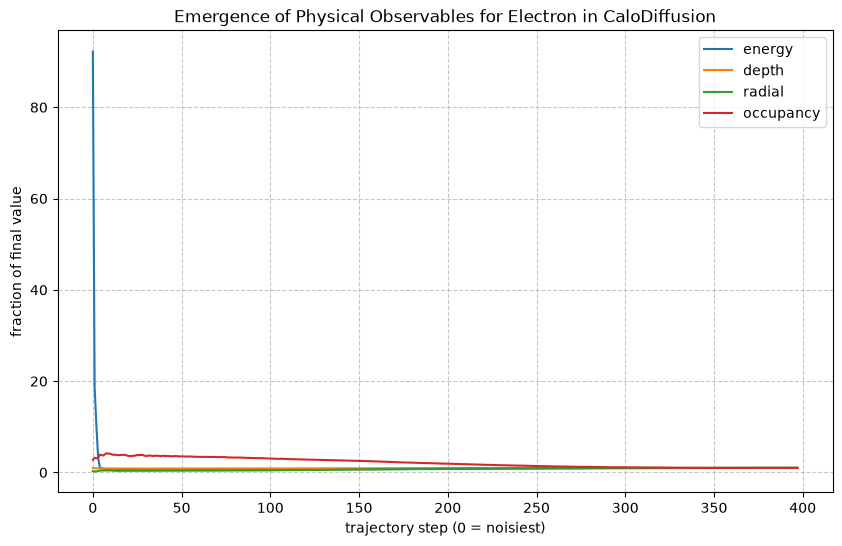

In [17]:
ecut = model.config['ECUT']
obs_fns = {'energy': total_energy, 'depth': depth,
           'radial': radial_spread, 'occupancy': lambda g: occupancy(g, ecut)}
curves = {name: [] for name in obs_fns}
for x0 in x0s:
    g = cp.to_physical_grid(model, x0, E_inc_gev)      # (n, layer, ang, rad) in GeV
    for name, fn in obs_fns.items():
        curves[name].append( np.median(fn(g)) )

# TODO: normalise each curve to its final value, then plot vs step.
plt.figure(figsize=(10,6))
for name, vals in curves.items():
     vals = np.array(vals) / vals[-1]
     plt.plot(vals, label=name)
plt.xlabel('trajectory step (0 = noisiest)'); plt.ylabel('fraction of final value')
plt.title('Emergence of Physical Observables for Electron in CaloDiffusion')
plt.grid(True, linestyle='--', alpha=0.7); plt.legend(); plt.savefig('Emergence_of_Physical_Observables_electron.png',dpi = 300) 
plt.show()

### 2d · The lock-in step + table  ⟵ **your job**
Define the **lock-in step** of an observable = the first step after which its (normalised)
curve stays within ~10% of its final value. Compute it for all four and make a small table.

*This scalar is the result* — it turns 'look at this plot' into a number you can compare
across particles (the nice-to-have).

In [18]:
def lock_in_step(norm_curve, tol=0.1):
    norm_curve = np.array(norm_curve)
    out_of_tol = np.abs(norm_curve - 1) > tol
    out_indices = np.where(out_of_tol)[0]
    if len(out_indices) == 0 :
        return 0
    lock_step = out_indices[-1] + 1
    return min(lock_step , len(norm_curve) - 1)

print(f"{'Observable':<15} | {'Lock-in Step':<12}")
print("-" * 30)
lock_in_results = {}
for name, vals in curves.items():
    # Re-normalize the curve to its final value
    norm_curve = np.array(vals) / vals[-1]
    # Calculate the lock-in step using the default 10% (0.1) tolerance
    step = lock_in_step(norm_curve, tol=0.1)
    lock_in_results[name] = step
    print(f"{name:<15} | {step:<12}")
        

Observable      | Lock-in Step
------------------------------
energy          | 275         
depth           | 135         
radial          | 229         
occupancy       | 304         


## Comparing the Lock-in Steps and Emergence Plots for Electrons, Photons and Pions

### The Main Functions and Lock-in Steps

In [19]:
def total_energy(raw):
    raw_flat = raw.reshape(raw.shape[0],-1)
    return raw_flat.sum(axis=1)

def depth(g):
    layer_energy = g.sum(axis=(2,3))
    layers = np.arange(g.shape[1])
    total_energy = layer_energy.sum(axis=1)
    return (layer_energy * layers).sum(axis=1) / total_energy

def radial_spread(g):
    radial_energy = g.sum(axis=(1,2))
    r = np.arange(g.shape[3])
    total_energy = radial_energy.sum(axis=1)
    mean_r = (radial_energy * r).sum(axis=1) / total_energy
    r_diff_sq = (r[np.newaxis, :] - mean_r[:, np.newaxis])**2
    var = (r_diff_sq * radial_energy).sum(axis=1) / total_energy
    return np.sqrt(var)

def occupancy(raw , ecut):
    raw_flat = raw.reshape(raw.shape[0],-1)
    hits = (raw_flat > ecut).sum(axis=1)
    return hits / raw_flat.shape[1]

def lock_in_step(norm_curve, tol=0.1):
    norm_curve = np.array(norm_curve)
    out_of_tol = np.abs(norm_curve - 1) > tol
    out_indices = np.where(out_of_tol)[0]
    if len(out_indices) == 0 :
        return 0
    lock_step = out_indices[-1] + 1
    return min(lock_step , len(norm_curve) - 1)

### Pipeline : 

In [34]:
particle_types = ['electron', 'photon', 'pion']
n_showers = 100
matched_energy = 50.0
E_inc_gev = [matched_energy] * n_showers

master_results = {}
lock_in_table = {}

for particle in particle_types:
    model = cp.load_model(particle)
    ecut = model.config['ECUT']
    E_cond = cp.encode_energy(particle , E_inc_gev)
    _, _, x0s = cp.sample(model, E_cond, debug = True)
    curves = {'energy': [], 'depth' : [], 'radial': [], 'occupancy': []}
    for x0 in x0s:
        g = cp.to_physical_grid(model, x0, E_inc_gev)
        curves['energy'].append(np.median(total_energy(g)))
        curves['depth'].append(np.median(depth(g)))
        curves['radial'].append(np.median(radial_spread(g)))
        curves['occupancy'].append(np.median(occupancy(g, ecut)))
    master_results[particle] = curves
    particle_lock_ins = {}
    for name, vals in curves.items():
        norm_curve = np.array(vals) / vals[-1]
        particle_lock_ins[name] = lock_in_step(norm_curve, tol=0.1)
    lock_in_table[particle] = particle_lock_ins

print("\n" + "="*55)
print(f"{'Observable':<15} | {'Electron':<10} | {'Photon':<10} | {'Pion':<10}")
print("="*55)
for obs in ['energy', 'depth', 'radial', 'occupancy']:
    print(f"{obs:<15} | {lock_in_table['electron'][obs]:<10} | {lock_in_table['photon'][obs]:<10} | {lock_in_table['pion'][obs]:<10}")
print("="*55)



 Model: 

SAMPLE ALGO : ddpm
Time for sampling 100 events is 24.85832166671753 seconds
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
d

#### Electron Emergence Plot

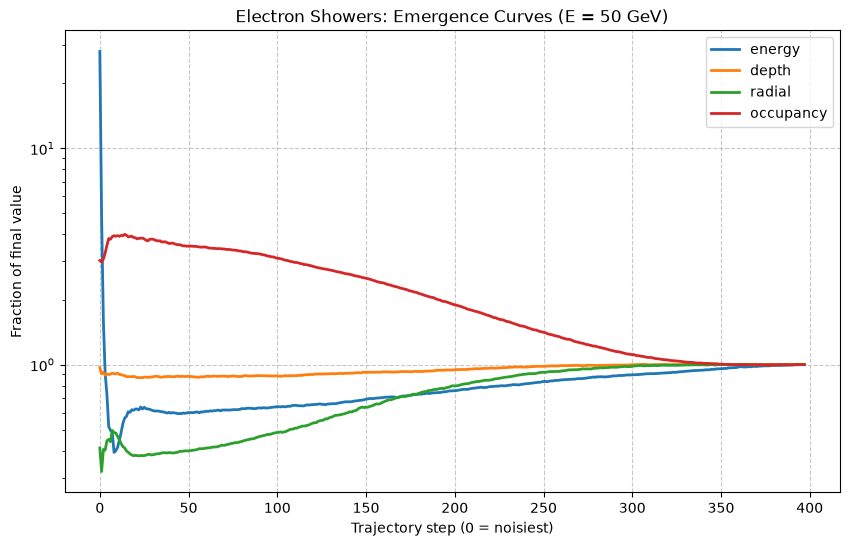

In [35]:
plt.figure(figsize=(10, 6))
for name, vals in master_results['electron'].items():
    norm_curve = np.array(vals) / vals[-1]
    plt.plot(norm_curve, label=name, linewidth=2)
    
plt.xlabel('Trajectory step (0 = noisiest)')
plt.yscale('log')
plt.ylabel('Fraction of final value')
plt.title('Electron Showers: Emergence Curves (E = 50 GeV)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Emergence_Curve-Electron[50GeV].png',dpi = 300) 
plt.show()

#### Photon Emergence Plot

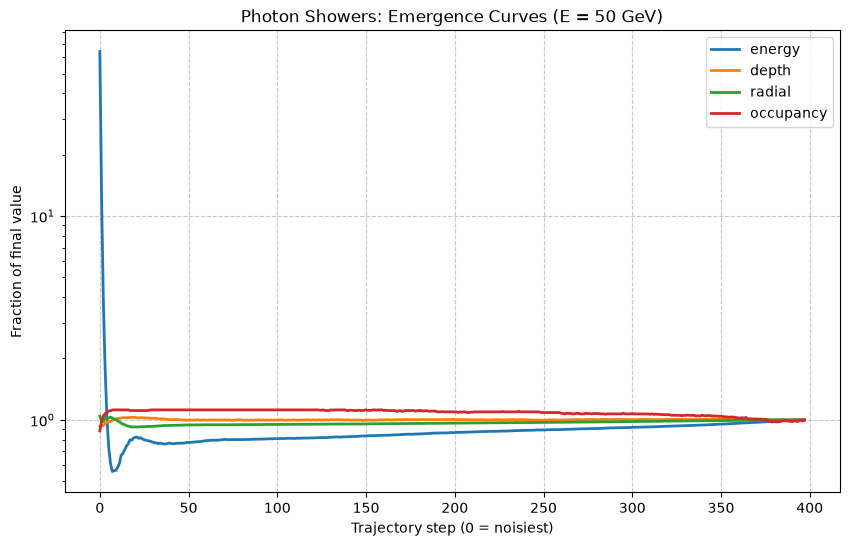

In [36]:
plt.figure(figsize=(10, 6))
for name, vals in master_results['photon'].items():
    norm_curve = np.array(vals) / vals[-1]
    plt.plot(norm_curve, label=name, linewidth=2)
    
plt.xlabel('Trajectory step (0 = noisiest)')
plt.yscale('log')
plt.ylabel('Fraction of final value')
plt.title('Photon Showers: Emergence Curves (E = 50 GeV)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Emergence_Curve-Photon[50GeV].png',dpi = 300)
plt.show()

#### Pion Emergence Plot

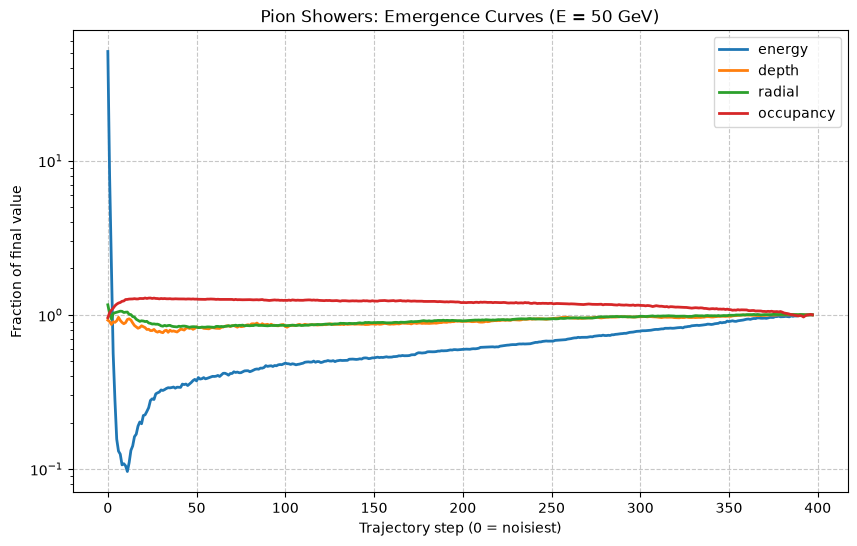

In [37]:
plt.figure(figsize=(10, 6))
for name, vals in master_results['pion'].items():
    norm_curve = np.array(vals) / vals[-1]
    plt.plot(norm_curve, label=name, linewidth=2)
    
plt.xlabel('Trajectory step (0 = noisiest)')
plt.ylabel('Fraction of final value')
plt.yscale('log')
plt.title('Pion Showers: Emergence Curves (E = 50 GeV)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Emergence_Curve-Pion[50GeV].png',dpi = 300)
plt.show()

# N_Runs and Uncertainity Bands

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Pipeline Configuration
BASE_SEED = 42
n_runs = 10
n_showers = 100  # Adjust based on your available compute
matched_energy = 50.0
E_inc_gev = [matched_energy] * n_showers
particles = ['electron', 'photon', 'pion']
observables = ['energy', 'depth', 'radial', 'occupancy']
master_data = {p: {obs: [] for obs in observables} for p in particles}

# The Multi-Run Loop
for run in range(n_runs):
    
    current_seed = BASE_SEED + run
    torch.manual_seed(current_seed)
    np.random.seed(current_seed)
    
    for particle in particles:
        model = cp.load_model(particle)
        ecut = model.config['ECUT']
        E_cond = cp.encode_energy(particle, E_inc_gev)
        _, _, x0s = cp.sample(model, E_cond, debug=True)
        run_curves = {obs: [] for obs in observables}
        
        for x0 in x0s:
            g = cp.to_physical_grid(model, x0, E_inc_gev)
            run_curves['energy'].append(np.median(total_energy(g)))
            run_curves['depth'].append(np.median(depth(g)))
            run_curves['radial'].append(np.median(radial_spread(g)))
            run_curves['occupancy'].append(np.median(occupancy(g, ecut)))
            
        # Normalize the curves against their final step (t=0) and store
        for obs in observables:
            raw_array = np.array(run_curves[obs])
            # Add epsilon to prevent divide-by-zero or log(0) issues
            final_val = raw_array[-1] + 1e-9 
            norm_curve = np.maximum(raw_array / final_val, 1e-6)
            master_data[particle][obs].append(norm_curve)





 Model: 

SAMPLE ALGO : ddpm
Time for sampling 100 events is 24.957000732421875 seconds
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2


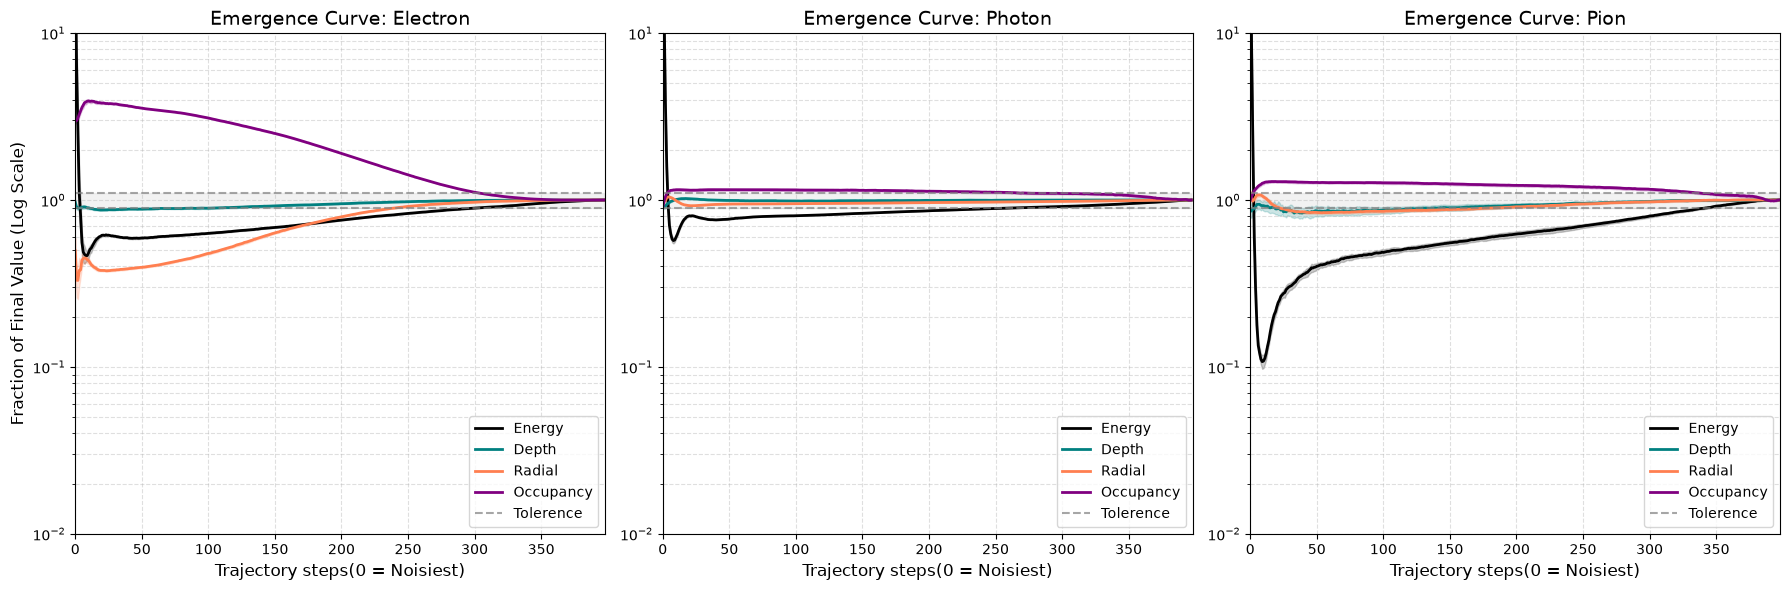

In [44]:
# Plotting with Uncertainty Bands (Log Scale)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {
    'energy': 'black',
    'depth': 'teal',
    'radial': 'coral',
    'occupancy': 'purple'
}

for idx, particle in enumerate(particles):
    ax = axes[idx]
    
    for obs in observables:
        # Stack the 5 runs into a 2D matrix of shape (5, n_steps)
        stacked_curves = np.vstack(master_data[particle][obs])
        
        # Calculate mean and standard deviation across the 5 runs
        mean_curve = np.mean(stacked_curves, axis=0)
        std_curve = np.std(stacked_curves, axis=0)
        n_steps = len(mean_curve)
        steps = np.arange(n_steps)
        ax.plot(steps, mean_curve, label=obs.capitalize(), color=colors[obs], linewidth=2)
        # Fill the uncertainty band (Mean +/- 1 StdDev)
        ax.fill_between(steps, 
                        np.maximum(mean_curve - std_curve, 1e-6), 
                        mean_curve + std_curve, 
                        color=colors[obs], alpha=0.2)

    ax.set_yscale('log')
    ax.set_ylim(1e-2, 10)  # Constrain Y-axis to relevant log decades
    ax.set_xlim(0, n_steps)
    
    # Plot the 10% Lock-in Tolerance Band
    ax.axhline(1.1, color='gray', linestyle='--', alpha=0.7, label = 'Tolerence')
    ax.axhline(0.9, color='gray', linestyle='--', alpha=0.7)
    ax.fill_between(steps, 0.9, 1.1, color='gray', alpha=0.1)
    
    
    ax.set_title(f"Emergence Curve: {particle.capitalize()}", fontsize=14)
    ax.set_xlabel("Trajectory steps(0 = Noisiest)", fontsize=12)
    
    if idx == 0:
        ax.set_ylabel("Fraction of Final Value (Log Scale)", fontsize=12)
        
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig('Log_Emergence_Uncertainty_Bands.png', dpi=300)
plt.show()

Saved highly detailed plot: Emergence_Band_Energy.png


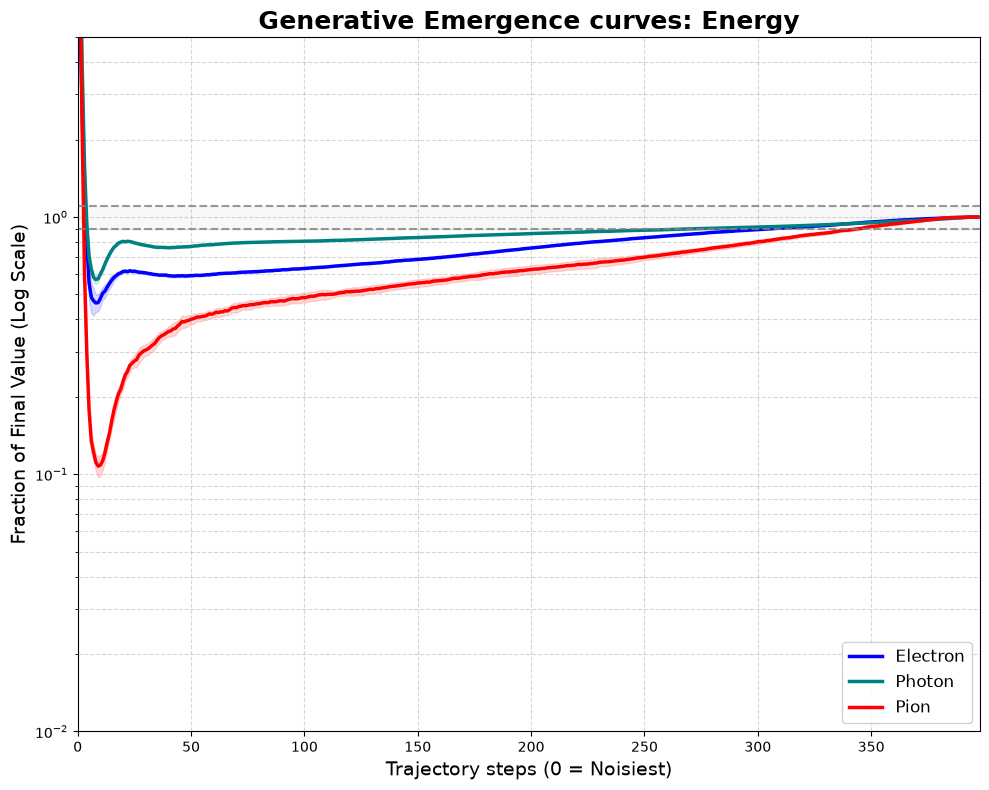

Saved highly detailed plot: Emergence_Band_Depth.png


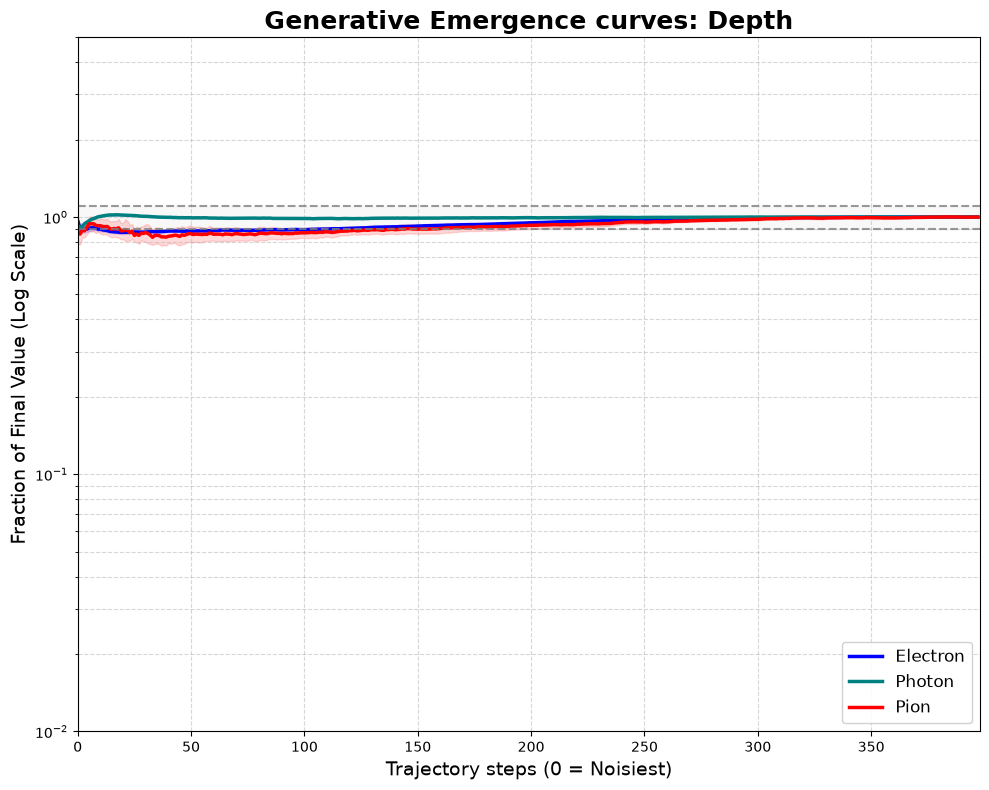

Saved highly detailed plot: Emergence_Band_Radial.png


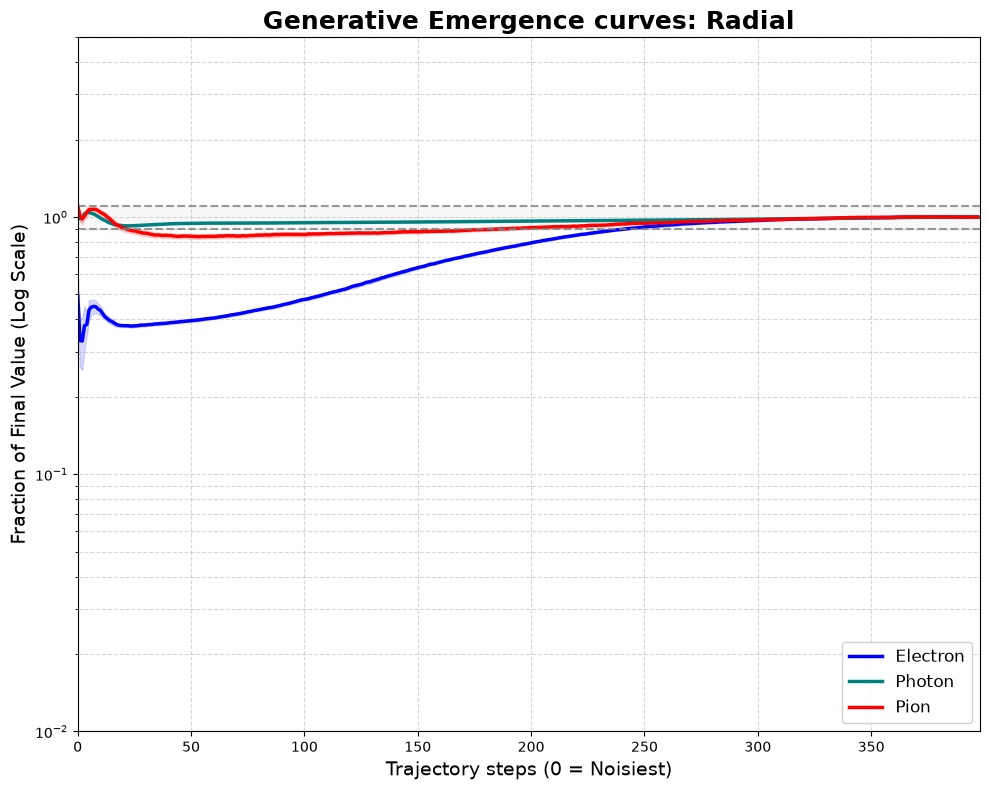

Saved highly detailed plot: Emergence_Band_Occupancy.png


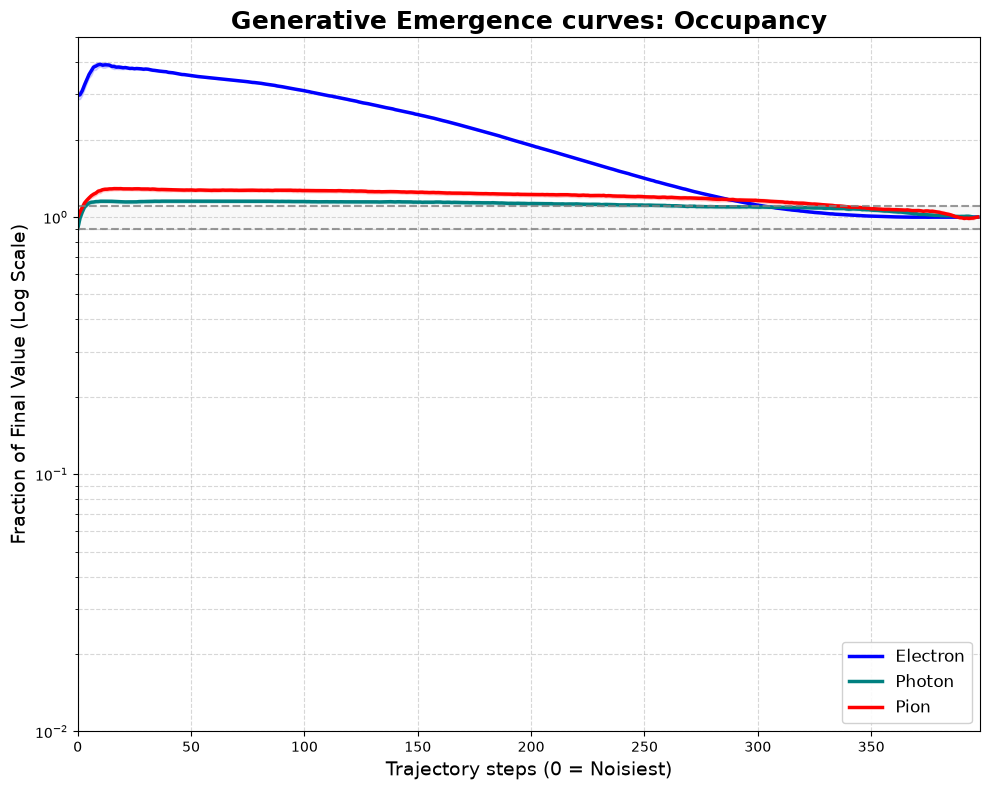

In [48]:
import numpy as np
import matplotlib.pyplot as plt
particles = ['electron', 'photon', 'pion']
observables = ['energy', 'depth', 'radial', 'occupancy']
particle_colors = {
    'electron': 'blue',    # Clean, stable baseline
    'photon': 'teal',      # Instant geometry
    'pion': 'red'          # Chaotic hadronic
}
for obs in observables:
    fig, ax = plt.subplots(figsize=(10, 8))
    for particle in particles:
        # Extract the stacked 10-run matrix for this specific particle and observable
        stacked_curves = np.vstack(master_data[particle][obs])
        
        mean_curve = np.mean(stacked_curves, axis=0)
        std_curve = np.std(stacked_curves, axis=0)
        
        steps = np.arange(len(mean_curve))
        color = particle_colors[particle]
        
        # Plot the mean line
        ax.plot(steps, mean_curve, label=f"{particle.capitalize()}", color=color, linewidth=2.5)
        
        # Fill the  uncertainty band
        ax.fill_between(steps, 
                        np.maximum(mean_curve - std_curve, 1e-6), 
                        mean_curve + std_curve, 
                        color=color, alpha=0.15)
    ax.set_yscale('log')
    ax.set_ylim(1e-2, 5) 
    ax.set_xlim(0, len(steps))
    
    # 10% Lock-in Tolerance Band
    ax.axhline(1.1, color='gray', linestyle='--', alpha=0.8, linewidth=1.5)
    ax.axhline(0.9, color='gray', linestyle='--', alpha=0.8, linewidth=1.5)
    ax.fill_between(steps, 0.9, 1.1, color='gray', alpha=0.05)
    ax.set_title(f"Generative Emergence curves: {obs.capitalize()}", fontsize=18, fontweight='bold')
    ax.set_xlabel("Trajectory steps (0 = Noisiest)", fontsize=14)
    ax.set_ylabel("Fraction of Final Value (Log Scale)", fontsize=14)
    ax.legend(loc='lower right', fontsize=12, framealpha=0.9)
    ax.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    filename = f"Emergence_Band_{obs.capitalize()}.png"
    plt.savefig(filename, dpi=300)
    print(f"Saved highly detailed plot: {filename}")
    plt.show()

In [45]:
# Statistical Lock-In Table Generation

print("\n" + "="*70)
print(f"{'Observable':<15} | {'Electron':<15} | {'Photon':<15} | {'Pion':<15}")
print("="*70)

for obs in observables:
    row_str = f"{obs.capitalize():<15} | "
    
    for particle in particles:
        # Calculate the lock-in step for each of the 5 runs independently
        run_lock_ins = []
        for curve in master_data[particle][obs]:
            # Using your existing lock_in_step function
            run_lock_ins.append(lock_in_step(curve, tol=0.1))
        
        # Calculate statistics
        mean_val = np.mean(run_lock_ins)
        std_val = np.std(run_lock_ins)
        
        # Format as "Mean +/- Std"
        stat_str = f"{mean_val:.1f} +/- {std_val:.1f}"
        row_str += f"{stat_str:<15} | "
        
    print(row_str)
print("="*70)


Observable      | Electron        | Photon          | Pion           
Energy          | 305.4 +/- 4.4   | 272.3 +/- 3.6   | 343.9 +/- 4.6   | 
Depth           | 112.6 +/- 15.2  | 0.9 +/- 1.4     | 157.5 +/- 52.4  | 
Radial          | 242.2 +/- 3.0   | 0.0 +/- 0.0     | 188.2 +/- 15.9  | 
Occupancy       | 304.2 +/- 1.1   | 282.8 +/- 40.6  | 340.8 +/- 8.6   | 


- We were supposed to look at the generative trajectory of the **CaloDiffusion** module, from pure noise to a fully realized physical state. According to the paper https://arxiv.org/abs/2308.03876, the module is able to denoise perfectly by 400 time steps.
- We try and isolate exactly when and how the module **resolves physical properties of simulated showers**.
- We try to analyze by comparing the **Electromagnetic (Electrons and Photons)** particles and **Hadronic(Pions)** particle showers across different simulated detector geometries i.e **Dataset 1 has Photons and Pions with 368 total voxels** which has lower resolution, coarse, irregular and geometry inspired from **ATLAS** and **Dataset 2 has Electrons with 6,480 total voxels** with higher resolution, fine, highly segmented and uses a **regular cylindrical grid**.

# Observations for 10 runs and 100 events:

### **Electron**
- **Trajectory: Depth (112.6) $\to$ Radial Spread (242.2) $\to$ Occupancy (304.2) $\to$ Energy (305.4)**.
- **Observation**: The electron provides textbook validation of spectral emergence theory. Working within a high-resolution, uniform grid, the diffusion model successfully resolves the low-frequency longitudinal macro-structure (Depth) very early in the reverse process. It then resolves radial spread, reserving the final 100 steps exclusively for refining the high-frequency micro-structure (Occupancy).
- **Variance Insight**: The extraordinarily tight variance on Occupancy (± 1.1 steps) proves that generating high-resolution electromagnetic showers is a highly stable, deterministic mathematical process at the micro-structural level.
- The **model establishes the coarse, macro-geometry (Depth) way before finalizing sparse micro-details (Occupancy)**.
- This proves that high-resolution detector grids demand immense denoising time to resolve fine structure and **proves the COARSE-TO-FINE-TRAJECTORY hypothesis true.**

### **Photon**
- **Trajectory: Radial Spread (0.0) $\to$ Depth (0.9) $\to$ Energy (272.3) $\to$ Occupancy (282.8).**
- **Observation**: Because the compact EM photon is generated natively on a highly coarse spatial grid, its macro-geometry is forced to lock in instantly. The model simply dumps the dense energy deposition into a few massive spatial bins, requiring essentially zero denoising steps to figure out the spatial boundaries.
- **Variance Insight**: Despite the instantaneous spatial lock-in, the Occupancy variance is violent (± 40.6 steps). This establishes that deciding the exact boolean threshold (active vs. empty) for massive voxels is highly sensitive to the initial boundary conditions of the noise matrix, forcing the model to delay this high-frequency decision until the late stages of generation.
- Proves that **coarse detector geometry eliminates the fine-structure delay for simple shapes**.
- Confined to a low-resolution grid, the model bypasses the typical denoising timeline and deposits the compact electromagnetic shape into a few massive bins almost instantly.

### **Pion**
- **Trajectory: Depth (157.5) $\to$ Radial Spread (188.2) $\to$ Occupancy (340.8) $\to$ Energy (343.9)**.
- **Observation**: The pion completely shatters the clean denoising timeline established by the electron. It takes the neural network significantly longer to resolve the basic hadronic macro-structure, and it requires nearly the entire 400-step trajectory just to balance fundamental energy conservation.
- **Variance Insight**: The massive variance in longitudinal Depth (± 52.4 steps) mathematically quantifies the chaotic, widely fluctuating nature of hadronic shower development. 
- Confirms that **highly fluctuating, messy hadronic physics delays generation**.
- Even while using the exact same low-resolution grid as the photon, the pion required large additional steps just to establish its macro-depth, proving that **complex particle interactions inherently stretch the coarse-to-fine gap**.
- The **computational effort required to map a pion's energy deposition is heavily dependent on the specific path dictated by the starting noise, proving that hadronic generation is inherently less stable than electromagnetic generation**.

## Inferences for now :

### The Coarse-to-Fine Generative Mechanism
The observation **confirms** that diffusion models inherently construct physical data in a **coarse-to-fine order**. **By measuring the lock-in step**, which is the point in the generation trajectory where an observable stabilizes within a 10% tolerance of its final physical value **we see a clear temporal hierarchy**. Macro-level geometric structures, like longitudinal shower **depth, are resolved early during denoising process**. In contrast, **sparse and highly detailed micro-structures, specifically the exact voxel occupancy and radial spread, require nearly the entire trajectory to stabilize**. The **model establishes the broad strokes of the energy deposition before fine-tuning the exact boundaries**.

### The Hadronic Complexity Gap
Comparing the emergence curves of photons and pions within the same irregular, coarse detector geometry (Dataset 1) shows us that the **internal complexity of the particle directly influences the generation timeline**. **Electromagnetic showers (photons), which are compact and highly predictable, achieved structural lock-in almost instantaneously**. Conversely, **hadronic showers (pions)**, known for deep, messy, and violently fluctuating energy deposits, **severely delayed the model's ability to resolve fine structure**. The pion required significantly more denoising steps to finalize its radial spread and occupancy, proving that the **coarse-to-fine temporal gap widens substantially when the model is forced to reconstruct complex, fluctuating hadronic physics**.

### The Detector Resolution Effect
**A cross-dataset comparison between electrons (Dataset 2: 6,480 uniform voxels) and photons (Dataset 1: 368 irregular voxels) isolated the effect of detector granularity on the generative process**. Despite both being electromagnetic particles with nearly identical underlying physical shower shapes, their lock-in steps varied drastically. **The low-resolution photon locked in its spatial observables immediately**. **The high-resolution electron required over 300 steps to achieve occupancy lock-in. This indicates that the delayed emergence of "fine structure" is heavily bottlenecked by the spatial resolution of the detector grid**.

---
## 3 · Where to go next

- **Nice-to-have (the headline):** repeat §2 for `'photon'` and `'pion'` at *matched* energies.
  Does the coarse→fine gap **widen** for the messy hadronic pion showers? → Table 2, Fig 3.
- **Optional (pick one, with us):** spectral emergence (azimuthal FFT, electron only) /
  conditioning intervention / a linear probe inside the U-Net. See `JUMPING_OFF_POINTS.md`.

Deliverables, milestones, and what's *out* of scope are all in `JUMPING_OFF_POINTS.md`.